# League Machine Learning Project

## 1. Setup

### 1.1 Loading the data

In [30]:
import pandas as pd

data_deleted = pd.read_parquet("data_processed/data_deleted.parquet")

print(f"Length of data: {len(data_deleted)}")
print(f"Data columns:\n {data_deleted.columns.tolist()}")

Length of data: 482188
Data columns:
 ['puuid', 'match_id', 'team', 'role', 'champion', 'traj_len', 'x0', 'y0', 'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4', 'x5', 'y5', 'x6', 'y6', 'x7', 'y7', 'x8', 'y8', 'x9', 'y9', 'x10', 'y10', 'x11', 'y11', 'x12', 'y12', 'x13', 'y13', 'x14', 'y14', 'x15', 'y15', 'x16', 'y16', 'x17', 'y17', 'x18', 'y18', 'x19', 'y19', 'x20', 'y20', 'x21', 'y21', 'x22', 'y22', 'x23', 'y23', 'x24', 'y24', 'x25', 'y25', 'x26', 'y26', 'x27', 'y27', 'x28', 'y28', 'x29', 'y29', 'x30', 'y30', 'x31', 'y31', 'x32', 'y32', 'x33', 'y33', 'x34', 'y34', 'x35', 'y35', 'x36', 'y36', 'x37', 'y37', 'x38', 'y38', 'x39', 'y39', 'x40', 'y40', 'x41', 'y41', 'x42', 'y42', 'x43', 'y43', 'x44', 'y44', 'x45', 'y45', 'x46', 'y46', 'x47', 'y47', 'x48', 'y48', 'x49', 'y49', 'x50', 'y50', 'x51', 'y51', 'x52', 'y52', 'x53', 'y53', 'x54', 'y54', 'x55', 'y55', 'x56', 'y56', 'x57', 'y57', 'x58', 'y58', 'x59', 'y59']


### 1.2 Setting random_state

In [31]:
random_state = 42

## 2. Trajectories - Visualization

### 2.1 Comparing different roles

In [72]:
import matplotlib.pyplot as plt
import numpy as np

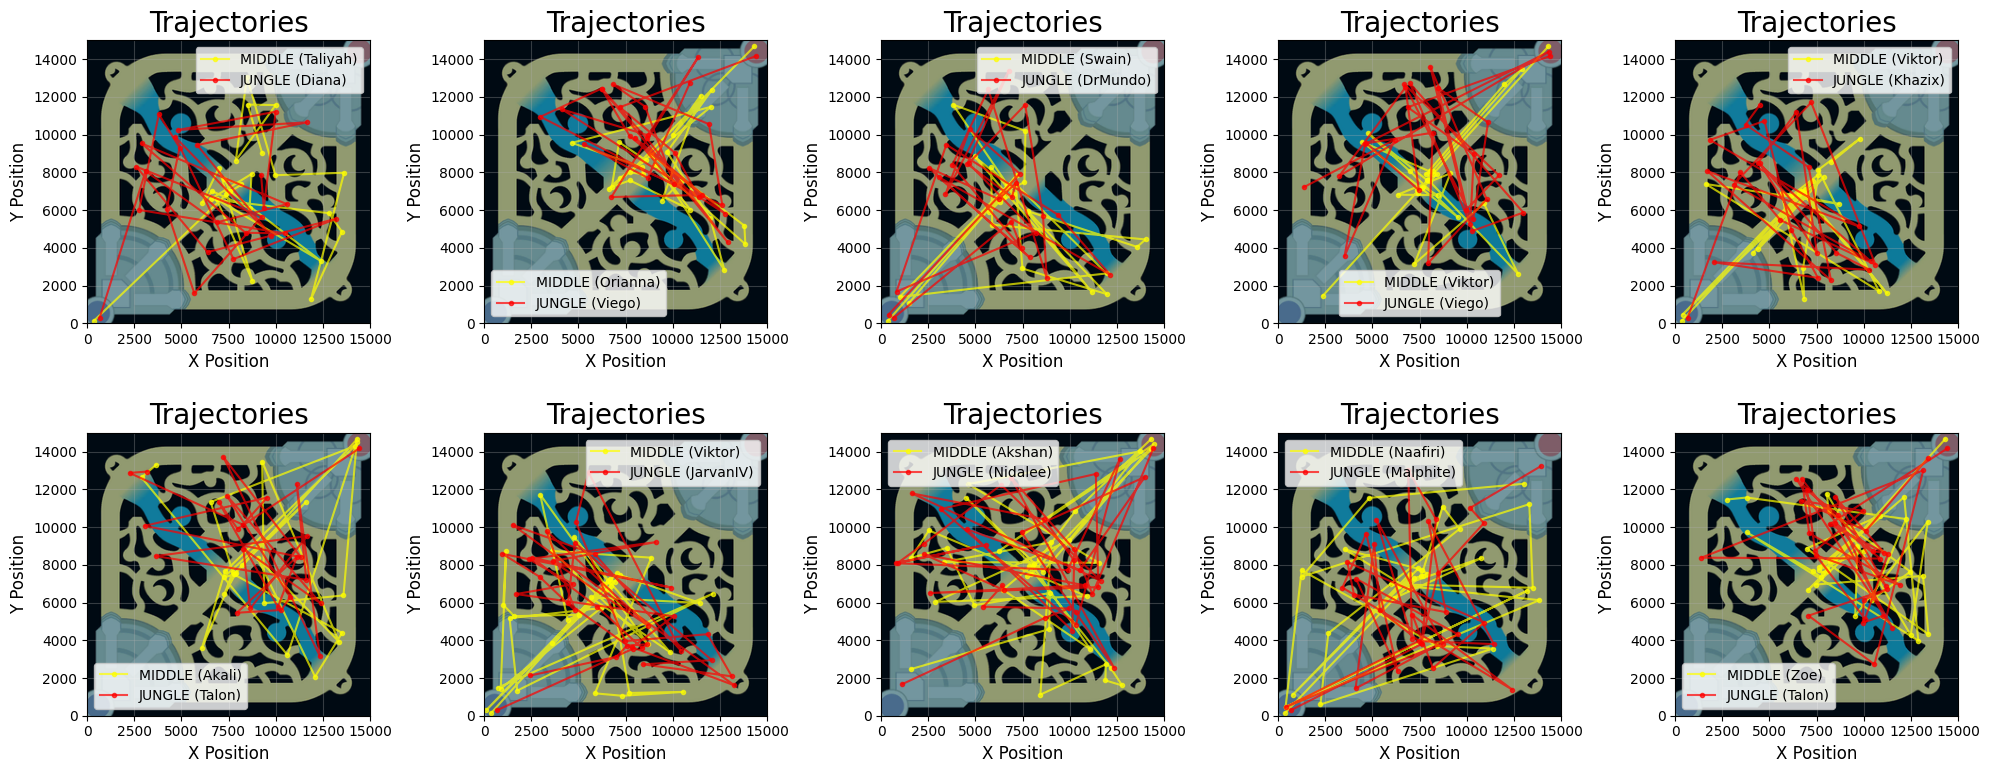

In [33]:

n_samples = 10
roles = ['MIDDLE', 'JUNGLE']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

colors = ['yellow','red','darkblue','orange','purple']

for i in range(len(roles)):
    role = roles[i]
    for idx in range(n_samples):
        ax = axes[idx]
        data_by_role = data_deleted[data_deleted['role'] == role]

        x_positions = [data_by_role.iloc[idx][f'x{i}'] for i in range(40)]
        y_positions = [data_by_role.iloc[idx][f'y{i}'] for i in range(40)]

        champion = data_by_role.iloc[idx]['champion']

        ax.plot(x_positions, y_positions, '-o', color= colors[i], markersize=3, linewidth=1.5, label=f"{role} ({champion})", alpha=0.7)

        ax.set_title(f'Trajectories', fontsize=20)
        ax.set_xlabel('X Position', fontsize=12)
        ax.set_ylabel('Y Position', fontsize=12)
        ax.set_xlim(0, 15000)
        ax.set_ylim(0, 15000)
        im = plt.imread("300px-Summoner's_Rift_Minimap.png")
        ax.imshow(im, extent=[0, 15000, 0, 15000])
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### 2.2 Histogram of trajectories length 

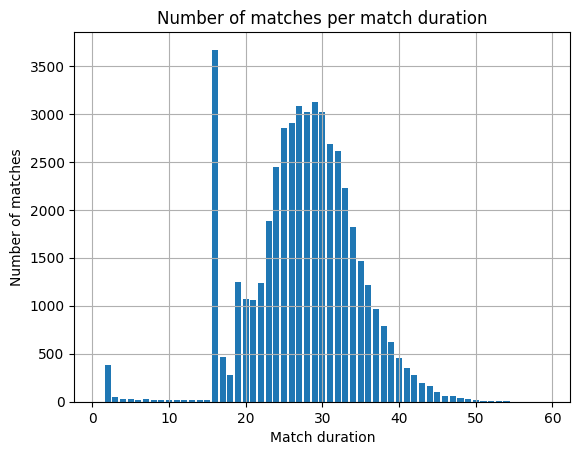

In [34]:
results = data_deleted.groupby(['match_id','traj_len']).size() 
results = results.groupby(['traj_len']).size()
minutes = results.index - 1

plt.figure()
plt.bar(minutes,results.values, align = 'center')

plt.xlabel('Match duration')
plt.ylabel('Number of matches')
plt.title('Number of matches per match duration')

plt.grid(True)
plt.show()

## 3. Baseline

### 3.1 Mapping
A good idea for the baseline would be a majority vote of roles for every champion.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [36]:
# Mapping
data_baseline = data_deleted[['champion', 'role']]

data_train, data_test = train_test_split(data_baseline, test_size=0.2,random_state=random_state)

model_map = data_train.groupby('champion')['role'].agg(lambda x: x.mode()[0])
y_pred_map = data_test['champion'].map(model_map)


# Models review
print("="*50)
print("MAPPING BASELINE")
print("="*50)
acc_map = accuracy_score(data_test['role'], y_pred_map)
print(f"Accuracy: {acc_map:.4f}")
print("\nClassification Report:")
print(classification_report(data_test['role'], y_pred_map))

MAPPING BASELINE
Accuracy: 0.8360

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.91      0.93      0.92     19547
      JUNGLE       0.78      0.84      0.81     19186
      MIDDLE       0.78      0.73      0.75     19336
         TOP       0.79      0.77      0.78     19178
     UTILITY       0.91      0.91      0.91     19191

    accuracy                           0.84     96438
   macro avg       0.84      0.84      0.83     96438
weighted avg       0.84      0.84      0.84     96438



### 3.2 Logistic Regression, same idea

In [37]:
# Logistic Regression
X = data_deleted[['champion']].copy()
y = data_deleted['role']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_state)

pipeline = Pipeline([
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=100, random_state=random_state))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("\n" + "="*50)
print("LOGISTIC REGRESSION")
print("="*50)
acc_lr = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


LOGISTIC REGRESSION
Accuracy: 0.8360

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.91      0.93      0.92     19547
      JUNGLE       0.78      0.84      0.81     19186
      MIDDLE       0.78      0.73      0.75     19336
         TOP       0.79      0.77      0.78     19178
     UTILITY       0.91      0.91      0.91     19191

    accuracy                           0.84     96438
   macro avg       0.84      0.84      0.83     96438
weighted avg       0.84      0.84      0.84     96438



### 3.3 Baseline comparison

In [38]:
print("\n" + "="*50)
print("PODSUMOWANIE")
print("="*50)
print(f"Mapping:     {acc_map:.4f}")
print(f"Logistic R.: {acc_lr:.4f}")
print(f"Difference:     {(acc_lr - acc_map):.4f}")


PODSUMOWANIE
Mapping:     0.8360
Logistic R.: 0.8360
Difference:     0.0000


## 4. Random Forest - Leakage

### 4.1 Training model

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:

position_cols = [col for col in data_deleted.columns if col.startswith(('x', 'y'))]
X = data_deleted[position_cols] 
y = data_deleted['role']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_state)

model_rf = RandomForestClassifier(n_estimators=50,random_state=random_state)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("="*50)
print("RANDOM FOREST")
print("="*50)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<20} {acc_map:.4f}")
print(f"{'Logistic Regression':<20} {acc_lr:.4f}")
print(f"{'Random Forest':<20} {acc_rf:.4f}")
print("="*70)

RANDOM FOREST
Accuracy: 0.9998

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       1.00      1.00      1.00     19547
      JUNGLE       1.00      1.00      1.00     19186
      MIDDLE       1.00      1.00      1.00     19336
         TOP       1.00      1.00      1.00     19178
     UTILITY       1.00      1.00      1.00     19191

    accuracy                           1.00     96438
   macro avg       1.00      1.00      1.00     96438
weighted avg       1.00      1.00      1.00     96438


Model                Accuracy       
----------------------------------------------------------------------
Mapping              0.8360
Logistic Regression  0.8360
Random Forest        0.9998


#### 4.1.1 Observation 

Having almost 100% accuracy is suspect ඞ.

### 4.2 Feature Importance

In [41]:
model_feature_importances = pd.DataFrame({
    'columns': model_rf.feature_names_in_,
    'importances': model_rf.feature_importances_,
    
})
model_feature_importances[model_feature_importances['importances']>0.03]

,columns,importances
0,x0,0.129079
1,y0,0.139783
2,x1,0.058491
3,y1,0.108322
4,x2,0.075069
5,y2,0.055711
6,x3,0.037109
7,y3,0.051326
8,x4,0.031870
11,y5,0.034590


No single feature has importance higher than 0.2, as we have 120 features to evaluate for importance. Even so we can notice that there is a rather sharp drop from  x0/y0 to x1/y1.

### 4.3 Training models with 1 variable

In [42]:
model_x0 = RandomForestClassifier(n_estimators=50, random_state=random_state)
model_x0.fit(X_train[['x0']],y_train)
y_pred_x0 = model_x0.predict(X_test[['x0']])

print("="*50)
print("MODEL WITH X0 AS THE SOLE FEATURE")
print("="*50)
acc_rf = accuracy_score(y_test, y_pred_x0)
print(f"Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<20} {acc_map:.4f}")
print(f"{'Logistic Regression':<20} {acc_lr:.4f}")
print(f"{'Random Forest':<20} {acc_rf:.4f}")
print("="*70)


MODEL WITH X0 AS THE SOLE FEATURE
Accuracy: 0.9999

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       1.00      1.00      1.00     19547
      JUNGLE       1.00      1.00      1.00     19186
      MIDDLE       1.00      1.00      1.00     19336
         TOP       1.00      1.00      1.00     19178
     UTILITY       1.00      1.00      1.00     19191

    accuracy                           1.00     96438
   macro avg       1.00      1.00      1.00     96438
weighted avg       1.00      1.00      1.00     96438


Model                Accuracy       
----------------------------------------------------------------------
Mapping              0.8360
Logistic Regression  0.8360
Random Forest        0.9999


In [43]:
model_y0 = RandomForestClassifier(n_estimators=50, random_state=random_state)
model_y0.fit(X_train[['y0']],y_train)
y_pred_y0 = model_y0.predict(X_test[['y0']])

print("="*50)
print("MODEL WITH Y0 AS THE SOLE FEATURE")
print("="*50)
acc_rf = accuracy_score(y_test, y_pred_y0)
print(f"Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<20} {acc_map:.4f}")
print(f"{'Logistic Regression':<20} {acc_lr:.4f}")
print(f"{'Random Forest':<20} {acc_rf:.4f}")
print("="*70)

MODEL WITH Y0 AS THE SOLE FEATURE
Accuracy: 0.9999

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       1.00      1.00      1.00     19547
      JUNGLE       1.00      1.00      1.00     19186
      MIDDLE       1.00      1.00      1.00     19336
         TOP       1.00      1.00      1.00     19178
     UTILITY       1.00      1.00      1.00     19191

    accuracy                           1.00     96438
   macro avg       1.00      1.00      1.00     96438
weighted avg       1.00      1.00      1.00     96438


Model                Accuracy       
----------------------------------------------------------------------
Mapping              0.8360
Logistic Regression  0.8360
Random Forest        0.9999


As we can see there is a data leakage caused by the first position's values. From further investigation, we now know that x0 and y0 are the spawn points of the champions when the game starts. As it turns out the places where the champions spawn are not random and are instead assigned based on player role.

### 4.4 Deleting data leakage

In [44]:
if 'x0' and 'y0' in data_deleted:
    data = data_deleted.drop(columns=['x0','y0'])
#this reduces the trajectories length by 1
data.head(5)

,puuid,match_id,team,role,champion,traj_len,x1,y1,x2,y2,...,x55,y55,x56,y56,x57,y57,x58,y58,x59,y59
0,mCG4W3ohaS1yeYuEIpAiXCgHPyOb_GsrpP_Yw6y7Y-88SI...,EUW1_7684872966,0,TOP,Ornn,25,1032.0,12131.0,1401.0,11087.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,QfvaTyT_3Ez0jaMf0_QzLaOqAwRGPKGg179xIKLtNoFoof...,EUW1_7684872966,0,JUNGLE,Diana,25,3101.0,8063.0,6883.0,5349.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,nJgPqmoqt_bWlQgnH9U3XDORpE9zbhgTz8HzEXRChAmH8u...,EUW1_7684872966,0,MIDDLE,Taliyah,25,7572.0,7012.0,7244.0,7647.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,D29BAybAOJFm1tgl1K_r9BOC_vHCgBNDPH6Bnjl628rDbh...,EUW1_7684872966,0,BOTTOM,Yasuo,25,10633.0,1241.0,10709.0,1448.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3XpUlB8N3-_zm4qB0JykZOtTsETI3GBCxXKe60EAUDNYrW...,EUW1_7684872966,0,UTILITY,Leona,25,11464.0,1854.0,10734.0,1746.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. KNN

### 5.1 KNN function definition

Our data contains NaN values, which KNeighborsClassifier does not support natively. To resolve this, we preprocess our data to handle missing values before fitting the model - we use imputer to fill missing values with the mean.

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer

In [ ]:

def knn(X, y, n_neighbors = 5, metric = 'euclidean'):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('knn', KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)

    # print("="*50)
    # print("KNN")
    # print("="*50)
    
    # print(f"Accuracy: {acc:.4f}")
    # print("\nClassification Report:")
    # print(classification_report(y_test, y_pred))

    return acc

### 5.2 KNN with different n_neighbors and metrics

In [26]:
def knn_accuracy_table(X, y, n_neighbors_list = [1, 3, 5, 7, 11, 15], metrics_list = ['euclidean', 'manhattan', 'chebyshev', 'cosine']):
    results = []

    for metric in metrics_list:
        for n in n_neighbors_list:
            try:
                acc = knn(X, y, n_neighbors=n, metric=metric)
            except Exception as e:
                print(f"metric={metric}, n={n}: {e}")
                acc = None
            results.append({'metric': metric, 'n_neighbors': n, 'accuracy': acc})
    
    results_df = pd.DataFrame(results)
    results_pivot = results_df.pivot(index='n_neighbors', columns='metric', values='accuracy')
    display(results_pivot)
    
    best_row = results_df.loc[results_df['accuracy'].idxmax()]
    print(f"Best accuracy: {best_row['accuracy']:.4f} (n_neighbors={best_row['n_neighbors']}, metric='{best_row['metric']}')")
    return best_row['accuracy']

### 5.3 Training model with all positions

Due to the large dataset size, we randomly sample 50,000 rows to make KNN training and evaluation feasible.

In [ ]:
position_cols = [col for col in data.columns if col.startswith(('x', 'y'))]
X = data[position_cols] 
y = data['role']

X_sample = X.sample(50000, random_state=random_state)
y_sample = y.loc[X_sample.index]

acc_knn = knn_accuracy_table(X_sample, y_sample)

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<20} {acc_map:.4f}")
print(f"{'Logistic Regression':<20} {acc_lr:.4f}")
print(f"{'KNN':<20} {acc_knn:.4f}")
print("="*70)

metric,chebyshev,cosine,euclidean,manhattan
n_neighbors,,,,
1,0.4841,0.7640,0.7631,0.7969
3,0.4621,0.7730,0.7716,0.8144
5,0.4466,0.7715,0.7723,0.8205
7,0.4426,0.7704,0.7696,0.8189
11,0.4353,0.7631,0.7683,0.8175
15,0.4281,0.7603,0.7613,0.8150


Best accuracy: 0.8205 (n_neighbors=5, metric='manhattan')

Model                Accuracy       
----------------------------------------------------------------------
Mapping              0.8360
Logistic Regression  0.8360
KNN                  0.8205


For the data with all positions included, the accuracy with the Chebyshev metric is low. This is because, in the later stages of the game, players spread out across the map, resulting in the largest differences between their positions. Since the Chebyshev metric measures the greatest single-axis distance between two points, it becomes highly sensitive to these outlier movements, making it less effective for distinguishing player roles when trajectories cover the entire game.

### 5.4 Training models with first n positions

#### 5.4.1 20 positions

In [ ]:
position_cols = [f'x{i}' for i in range(1,21)] + [f'y{i}' for i in range(1,21)]
X = data[position_cols]
y = data['role']

X_sample = X.sample(50000, random_state=random_state)
y_sample = y.loc[X_sample.index]

acc_knn20 = knn_accuracy_table(X_sample, y_sample)

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<20} {acc_map:.4f}")
print(f"{'Logistic Regression':<20} {acc_lr:.4f}")
print(f"{'KNN':<20} {acc_knn:.4f}")
print(f"{'KNN - first 20':<20} {acc_knn20:.4f}")
print("="*70)

metric,chebyshev,cosine,euclidean,manhattan
n_neighbors,,,,
1,0.5982,0.8042,0.8017,0.8345
3,0.5741,0.8114,0.8068,0.8436
5,0.5530,0.8116,0.8103,0.8458
7,0.5464,0.8133,0.8086,0.8448
11,0.5259,0.8066,0.8035,0.8404
15,0.5150,0.8064,0.7987,0.8345


Best accuracy: 0.8458 (n_neighbors=5, metric='manhattan')

Model                Accuracy       
----------------------------------------------------------------------
Mapping              0.8360
Logistic Regression  0.8360
KNN                  0.8205
KNN - first 20       0.8458


#### 5.4.2 12 positions

In [ ]:
position_cols = [f'x{i}' for i in range(1,13)] + [f'y{i}' for i in range(1,13)]
X = data[position_cols]
y = data['role']

X_sample = X.sample(50000, random_state=random_state)
y_sample = y.loc[X_sample.index]

acc_knn12 = knn_accuracy_table(X_sample, y_sample)

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<20} {acc_map:.4f}")
print(f"{'Logistic Regression':<20} {acc_lr:.4f}")
print(f"{'KNN':<20} {acc_knn:.4f}")
print(f"{'KNN - first 20':<20} {acc_knn20:.4f}")
print(f"{'KNN - first 12':<20} {acc_knn12:.4f}")
print("="*70)

metric,chebyshev,cosine,euclidean,manhattan
n_neighbors,,,,
1,0.7892,0.8516,0.8533,0.8557
3,0.7760,0.8585,0.8638,0.8691
5,0.7654,0.8602,0.8625,0.8716
7,0.7551,0.8592,0.8635,0.8726
11,0.7388,0.8573,0.8586,0.8693
15,0.7211,0.8524,0.8552,0.8685


Best accuracy: 0.8726 (n_neighbors=7, metric='manhattan')

Model                Accuracy       
----------------------------------------------------------------------
Mapping              0.8360
Logistic Regression  0.8360
KNN                  0.8205
KNN - first 20       0.8458
KNN - first 12       0.8726


#### 5.4.3 5 positions

In [ ]:
position_cols = [f'x{i}' for i in range(1,6)] + [f'y{i}' for i in range(1,6)]
X = data[position_cols]
y = data['role']

X_sample = X.sample(50000, random_state=random_state)
y_sample = y.loc[X_sample.index]

acc_knn5 = knn_accuracy_table(X_sample, y_sample)

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<20} {acc_map:.4f}")
print(f"{'Logistic Regression':<20} {acc_lr:.4f}")
print(f"{'KNN':<20} {acc_knn:.4f}")
print(f"{'KNN - first 20':<20} {acc_knn20:.4f}")
print(f"{'KNN - first 12':<20} {acc_knn12:.4f}")
print(f"{'KNN - first 5':<20} {acc_knn5:.4f}")
print("="*70)

metric,chebyshev,cosine,euclidean,manhattan
n_neighbors,,,,
1,0.8294,0.8315,0.8380,0.8398
3,0.8415,0.8445,0.8511,0.8555
5,0.8439,0.8456,0.8523,0.8590
7,0.8453,0.8458,0.8537,0.8604
11,0.8458,0.8513,0.8577,0.8595
15,0.8436,0.8521,0.8581,0.8602


Best accuracy: 0.8604 (n_neighbors=7, metric='manhattan')

Model                Accuracy       
----------------------------------------------------------------------
Mapping              0.8360
Logistic Regression  0.8360
KNN                  0.8205
KNN - first 20       0.8458
KNN - first 12       0.8726
KNN - first 5        0.8604


When we reduce the number of initial positions used for classification, we observe an increase in accuracy. This makes sense, as the early phase of the game is the most influential for determining a player's role — during this time, players are positioned on their assigned lanes, making their roles more distinguishable.

## 6. Random Forest

### 6.1 Training model with all trajectories

In [45]:

position_cols = [col for col in data.columns if col.startswith(('x', 'y'))]
X = data[position_cols] 
y = data['role']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

model_rf_full = RandomForestClassifier(n_estimators=50,random_state=random_state)
model_rf_full.fit(X_train, y_train)
y_pred_rf = model_rf_full.predict(X_test)

print("="*50)
print("RANDOM FOREST")
print("="*50)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<20} {acc_map:.4f}")
print(f"{'Logistic Regression':<20} {acc_lr:.4f}")
print(f"{'Random Forest':<20} {acc_rf:.4f}")
print("="*70)

RANDOM FOREST
Accuracy: 0.9202

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.78      0.85      0.82     19547
      JUNGLE       0.99      1.00      1.00     19186
      MIDDLE       1.00      1.00      1.00     19336
         TOP       1.00      1.00      1.00     19178
     UTILITY       0.83      0.76      0.79     19191

    accuracy                           0.92     96438
   macro avg       0.92      0.92      0.92     96438
weighted avg       0.92      0.92      0.92     96438


Model                Accuracy       
----------------------------------------------------------------------
Mapping              0.8360
Logistic Regression  0.8360
Random Forest        0.9202


In [46]:
confusion_table20 = pd.crosstab(
    y_pred_rf,
    y_test,
    rownames=["Predicted role"],
    colnames=["Real role"]
)
confusion_table20

Real role,BOTTOM,JUNGLE,MIDDLE,TOP,UTILITY
Predicted role,,,,,
BOTTOM,16632,0,1,0,4611
JUNGLE,10,19174,86,15,50
MIDDLE,0,1,19245,0,1
TOP,0,3,2,19163,3
UTILITY,2905,8,2,0,14526


### 6.2 Training models with first n trajectories

Based on the observation of feature importance from the first random forest, we could see that the coordinates loose their importance with every minute of the game. Which matches with our intuition, as after about 15 minutes most players start moving around the whole map, causing the coordinates to become more chaotic and overlap with other players.

We will test the accuracy of the same algorithms, but with position data limited to the first n minutes.

#### 6.2.1 20 positions


In [47]:
position_cols = [f'x{i}' for i in range(1,21)] + [f'y{i}' for i in range(1,21)]
X = data[position_cols]
y = data['role']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_state)

model_rf = RandomForestClassifier(n_estimators=50, random_state=random_state)
model_rf.fit(X_train, y_train)
y_pred_rf20 = model_rf.predict(X_test)

print("="*50)
print("RANDOM FOREST 20")
print("="*50)
acc_rf20 = accuracy_score(y_test, y_pred_rf20)
print(f"Accuracy: {acc_rf20:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf20))

print("\n" + "="*70)
print(f"{'Model':<30} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<30} {acc_map:.4f}")
print(f"{'Logistic Regression':<30} {acc_lr:.4f}")
print(f"{'Random Forest':<30} {acc_rf:.4f}")
print("="*70)


RANDOM FOREST 20
Accuracy: 0.9256

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.80      0.86      0.83     19547
      JUNGLE       0.99      1.00      1.00     19186
      MIDDLE       1.00      1.00      1.00     19336
         TOP       1.00      1.00      1.00     19178
     UTILITY       0.85      0.77      0.81     19191

    accuracy                           0.93     96438
   macro avg       0.93      0.93      0.93     96438
weighted avg       0.93      0.93      0.93     96438


Model                          Accuracy       
----------------------------------------------------------------------
Mapping                        0.8360
Logistic Regression            0.8360
Random Forest                  0.9202


#### 6.2.2 Error Analisys for 20 positions

In [48]:
confusion_table20 = pd.crosstab(
    y_pred_rf20,
    y_test,
    rownames=["Predicted role"],
    colnames=["Real role"]
)
confusion_table20

Real role,BOTTOM,JUNGLE,MIDDLE,TOP,UTILITY
Predicted role,,,,,
BOTTOM,16853,0,2,0,4341
JUNGLE,12,19173,51,18,47
MIDDLE,0,0,19278,0,1
TOP,0,3,3,19160,5
UTILITY,2682,10,2,0,14797


#### 6.2.3 12 positions

In [ ]:
position_cols = [f'x{i}' for i in range(1,13)] + [f'y{i}' for i in range(1,13)]
X = data[position_cols]
y = data['role']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_state)

model_rf = RandomForestClassifier(n_estimators=50, random_state=random_state)
model_rf.fit(X_train, y_train)
y_pred_rf12 = model_rf.predict(X_test)

print("="*50)
print("RANDOM FOREST 12")
print("="*50)
acc_rf12 = accuracy_score(y_test, y_pred_rf12)
print(f"Accuracy: {acc_rf12:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf12))

print("\n" + "="*70)
print(f"{'Model':<30} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<30} {acc_map:.4f}")
print(f"{'Logistic Regression':<30} {acc_lr:.4f}")
print(f"{'Random Forest':<30} {acc_rf:.4f}")
print("="*70)


RANDOM FOREST 12
Accuracy: 0.9226

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.79      0.85      0.82     19547
      JUNGLE       0.99      1.00      1.00     19186
      MIDDLE       1.00      1.00      1.00     19336
         TOP       1.00      1.00      1.00     19178
     UTILITY       0.84      0.77      0.80     19191

    accuracy                           0.92     96438
   macro avg       0.92      0.92      0.92     96438
weighted avg       0.92      0.92      0.92     96438


Model                          Accuracy       
----------------------------------------------------------------------
Mapping                        0.8360
Logistic Regression            0.8360
Random Forest                  0.9202


#### 6.2.4 Error Analisys for 12 positions

In [18]:
confusion_table12 = pd.crosstab(
    y_pred_rf12,
    y_test,
    rownames=["Predicted role"],
    colnames=["Real role"]
)
confusion_table12

Real role,BOTTOM,JUNGLE,MIDDLE,TOP,UTILITY
Predicted role,,,,,
BOTTOM,16653,0,1,0,4436
JUNGLE,11,19171,48,17,41
MIDDLE,1,1,19283,0,1
TOP,0,3,3,19161,5
UTILITY,2882,11,1,0,14708


#### 6.2.5 5 positions

In [ ]:
position_cols = [f'x{i}' for i in range(1,6)] + [f'y{i}' for i in range(1,6)]
X = data[position_cols]
y = data['role']



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

model_rf = RandomForestClassifier(n_estimators=50, random_state=random_state)
model_rf.fit(X_train, y_train)
y_pred_rf5 = model_rf.predict(X_test)

print("="*50)
print("RANDOM FOREST 5")
print("="*50)
acc_rf5 = accuracy_score(y_test, y_pred_rf5)
print(f"Accuracy: {acc_rf5:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf5))

print("\n" + "="*70)
print(f"{'Model':<30} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<30} {acc_map:.4f}")
print(f"{'Logistic Regression':<30} {acc_lr:.4f}")
print(f"{'Random Forest':<30} {acc_rf:.4f}")
print(f"{'Random Forest - first 20':<30} {acc_rf20:.4f}")
print("="*70)

RANDOM FOREST 5
Accuracy: 0.8863

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.71      0.77      0.73     19547
      JUNGLE       0.99      1.00      1.00     19186
      MIDDLE       1.00      1.00      1.00     19336
         TOP       1.00      1.00      1.00     19178
     UTILITY       0.74      0.67      0.70     19191

    accuracy                           0.89     96438
   macro avg       0.89      0.89      0.89     96438
weighted avg       0.89      0.89      0.89     96438


Model                          Accuracy       
----------------------------------------------------------------------
Mapping                        0.8360
Logistic Regression            0.8360
Random Forest                  0.9202
Random Forest - first 20       0.9256


#### 6.2.6 Error analisys for 5 positions

In [20]:
confusion_table5 = pd.crosstab(
    y_pred_rf5,
    y_test,
    rownames=["Predicted role"],
    colnames=["Real role"]
)
confusion_table5

Real role,BOTTOM,JUNGLE,MIDDLE,TOP,UTILITY
Predicted role,,,,,
BOTTOM,14971,0,1,0,6261
JUNGLE,12,19162,42,17,35
MIDDLE,0,8,19289,1,1
TOP,0,5,3,19160,5
UTILITY,4564,11,1,0,12889


As we can see the accuracy has improved somehow compared to the full data for the 20 and 12 positions version.
Besides that we are steadily loosing accuracy with each data column lost, but it not proportional to the % of columns. Meaning that the first minutes of the game are in most cases enough to guess the role. 

There are some trade offs however:

- The 20 and 12 models classify Bot/Utility better, as after the first 5 minutes of the game, most supports start to roam to other lanes or to help their jungle, which lets us separate them from Bot, which in most cases stays on their lane to farm minions.

- The first 5 model classifies Jungle a little bit better, as most roaming supports and midlaners do so after the 5 minute mark, which causes them to be classified as Jungle when they roam through the jungle too often.

Seeing as jungle missclassifications are minimal (10s/100s) comapred to Bot/Utility missclasifications (1000s) the 20/12 models perform better. Although we will need to think of a better strategy to differentiate Bot and Utility.

## 7. Boosting

Random Forest averages independent trees and may struggle with subtle feature interactions. Boosting methods sequentially correct previous errors and are known to perform better on structured tabular data.

### 7.1 Gradient Boosting

In [49]:
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier

position_cols = [col for col in data.columns if col.startswith(('x', 'y'))]
X = data[position_cols] 
y = data['role']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

model_gb = HistGradientBoostingClassifier(
    max_iter=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=random_state
)

model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

print("="*50)
print("GRADIENT BOOST")
print("="*50)
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f"Accuracy: {acc_gb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\n" + "="*70)
print(f"{'Model':<30} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<30} {acc_map:.4f}")
print(f"{'Logistic Regression':<30} {acc_lr:.4f}")
print(f"{'Random Forest':<30} {acc_rf:.4f}")
print(f"{'Random Forest - first 20':<30} {acc_rf20:.4f}")
print("="*70)


GRADIENT BOOST
Accuracy: 0.9296

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.80      0.89      0.84     19547
      JUNGLE       0.99      1.00      0.99     19186
      MIDDLE       1.00      1.00      1.00     19336
         TOP       1.00      1.00      1.00     19178
     UTILITY       0.87      0.77      0.82     19191

    accuracy                           0.93     96438
   macro avg       0.93      0.93      0.93     96438
weighted avg       0.93      0.93      0.93     96438


Model                          Accuracy       
----------------------------------------------------------------------
Mapping                        0.8360
Logistic Regression            0.8360
Random Forest                  0.9202
Random Forest - first 20       0.9256


In [66]:
confusion_table_gb = pd.crosstab(
    y_pred_gb,
    y_test,
    rownames=["Predicted role"],
    colnames=["Real role"]
)
confusion_table_gb

Real role,BOTTOM,JUNGLE,MIDDLE,TOP,UTILITY
Predicted role,,,,,
BOTTOM,17262,18,13,73,3687
JUNGLE,14,19043,28,46,50
MIDDLE,4,19,19184,4,7
TOP,73,83,109,19051,135
UTILITY,2194,23,2,4,15312


We can see that the Gradient Boost algorithm improved our BOT/UTILITY accuracy a bit, but at the same times makes more mistakes while classifiing other roles (Anything => JUNGLE). Which does not have enough impact to offset the accuracy improvement from BOT/UTILITY classification.

### 7.2 Elbow curve based on num of coordinates in gradient boost

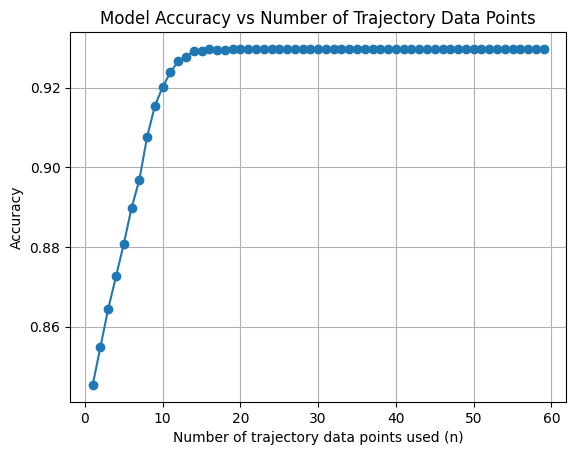

In [69]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=random_state)

res = []
for n in range(1,60):
    position_cols = [f'x{i}' for i in range(1,n+1)] + [f'y{i}' for i in range(1,n+1)]
    X_train_i = X_train[position_cols]
    X_test_i = X_test[position_cols]

    model_gb_i = HistGradientBoostingClassifier(
    max_iter=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=random_state
)
    model_gb_i.fit(X_train_i,y_train)
    y_pred_gb_i = model_gb_i.predict(X_test_i)

    accuracy_i = accuracy_score(y_test, y_pred_gb_i)
    res.append(accuracy_i)
    

n_values = list(range(1, 60))

plt.figure()
plt.plot(n_values, res, marker='o')

plt.xlabel('Number of trajectory data points used (n)')
plt.ylabel('Accuracy')
plt.title('Model Accuracy vs Number of Trajectory Data Points')

plt.grid(True)
plt.show()

This is quite funny as 15 minute marks the first possibility of voting for surrender.

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

position_cols = [f'x{i}' for i in range(1, res.index(max(res)) + 2)] + [f'y{i}' for i in range(1, res.index(max(res)) + 2)]
#z racji ze zaczynamy liczbe trajektori od 1, a indeksowanie liste zaczyna sie od 0 to musimy dodac +1
#musimy tez dodac +1 z racji, ze drugi argument range to przedzial otwarty, dlatego +2

model_gb_best = HistGradientBoostingClassifier(
    max_iter=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=random_state
)

model_gb_best.fit(X_train[position_cols], y_train)
y_pred_gb_best = model_gb_best.predict(X_test[position_cols])

print("="*50)
print(f"GRADIENT BOOST - Frist {res.index(max(res)) + 1} minutes")
print("="*50)
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f"Accuracy: {acc_gb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))


confusion_table_gb_best = pd.crosstab(
    y_pred_gb_best,
    y_test,
    rownames=["Predicted role"],
    colnames=["Real role"]
)

confusion_table_gb_best


GRADIENT BOOST - Frist 16 minutes
Accuracy: 0.9296

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.80      0.89      0.84     19547
      JUNGLE       0.99      1.00      0.99     19186
      MIDDLE       1.00      1.00      1.00     19336
         TOP       1.00      1.00      1.00     19178
     UTILITY       0.87      0.77      0.82     19191

    accuracy                           0.93     96438
   macro avg       0.93      0.93      0.93     96438
weighted avg       0.93      0.93      0.93     96438



Real role,BOTTOM,JUNGLE,MIDDLE,TOP,UTILITY
Predicted role,,,,,
BOTTOM,17287,6,10,6,4313
JUNGLE,14,19137,42,21,61
MIDDLE,2,14,19275,2,1
TOP,0,0,3,19149,4
UTILITY,2244,29,6,0,14812


## 8. Buddy Isolation Score

### 8.1 Buddy score - minutes 5 - 20

So Our main problem is BOT/UTILITY miscalssification, so we need to create some metric derived from our trajectory data that would let the models have another feature which would help them make the distinction between the two. 

Earlier we were talking about how supports in high elo tend to roam after some time leaving their adc alone. We can use this fact to create the Buddy/Isolation score - a measure of how close a player is to the nearest allied champion between minutes 5 and 20.

**Why does this score make sense?**

Because as the support roams, the adc score will grow, as in most cases the support is the closes one to the adc. While the supports score would stay at a lower level as he would be closer to other lanes champions while roaming.

The score is will be the summed up distance from the closest champion to the player.

#### 8.1.1 Buddy score

In [117]:

def compute_buddy_score(group, t_start = 5, t_end = 20):
    """
    group: DataFrame containing players from ONE match and ONE team \n
    returns: pd.Series of buddy isolation scores indexed like group
    """
    n_players = len(group)
    scores = np.zeros(n_players)

    for m in range(t_start, t_end):
        xs = group[f'x{m}'].to_numpy()
        ys = group[f'y{m}'].to_numpy()

        positions = np.column_stack((xs, ys))

        for i in range(n_players):
            dx = positions[:, 0] - positions[i, 0]
            dy = positions[:, 1] - positions[i, 1]
            dists = np.sqrt(dx**2 + dy**2)

            dists[i] = np.inf

            scores[i] += np.min(dists)

    return pd.Series(scores, index=group.index)



In [118]:
time_frames = [
    (5,10),
    (10,15),
    (15,20),
    (20,25)
]

for time_constraints in time_frames:
    data[f'buddy_isolation_score_{time_constraints[0]}-{time_constraints[1]}'] = (
        data
        .groupby(['match_id', 'team'], group_keys=False)
        .apply(lambda x: compute_buddy_score(x, time_constraints[0], time_constraints[1]))
    )

C:\Users\kacpe\AppData\Local\Temp\ipykernel_7172\2608104681.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_buddy_score(x, time_constraints[0], time_constraints[1]))
C:\Users\kacpe\AppData\Local\Temp\ipykernel_7172\2608104681.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_buddy_score(x, time_constraints[0], time_constraints[1]))
C:\Users\kacpe\AppData\Local

In [120]:
for time_constraints in time_frames:
    print(data.groupby('role')[f'buddy_isolation_score_{time_constraints[0]}-{time_constraints[1]}'].mean())


role
BOTTOM     10436.392213
JUNGLE     13684.185160
MIDDLE     18343.934243
TOP        28929.166643
UTILITY     7281.880194
Name: buddy_isolation_score_5-10, dtype: float64
role
BOTTOM     11522.950181
JUNGLE     12463.451975
MIDDLE     17476.429560
TOP        28867.525994
UTILITY     7832.139374
Name: buddy_isolation_score_10-15, dtype: float64
role
BOTTOM     10710.828246
JUNGLE     10518.745596
MIDDLE     16350.535264
TOP        20918.281152
UTILITY     7431.133310
Name: buddy_isolation_score_15-20, dtype: float64
role
BOTTOM      8152.782587
JUNGLE      9103.071815
MIDDLE     13256.157396
TOP        15842.512243
UTILITY     6798.448868
Name: buddy_isolation_score_20-25, dtype: float64


As we can see the score has lower values for support than for adc in every time frame. Which should help us in separtaing these 2 roles.

Let's test the impact of the score on our boosting model.

In [131]:
data['buddy_isolation_score'] = data[[f'buddy_isolation_score_{time_constraints[0]}-{time_constraints[1]}' for time_constraints in time_frames]].sum(axis=1)

#### 8.1.2 Buddy score from 5-20 minutes + the first 16 minutes

In [ ]:

cols = [f"x{i}" for i in range (1,17)] + [f"y{i}" for i in range (1,17)] + [f'buddy_isolation_score_{time_constraints[0]}-{time_constraints[1]}' for time_constraints in time_frames] 
cols.append('buddy_isolation_score')
X = data[cols]
y = data['role']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)


model_gb_buddy = HistGradientBoostingClassifier(
    max_iter=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=random_state
)

model_gb_buddy.fit(X_train, y_train)
y_pred_gb_buddy = model_gb_buddy.predict(X_test)

print("="*50)
print(f"GRADIENT BOOST - Buddy Score and first 16 minutes")
print("="*50)
acc_gb_buddy = accuracy_score(y_test, y_pred_gb_buddy)
print(f"Accuracy: {acc_gb_buddy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb_buddy))


confusion_table_gb_buddy = pd.crosstab(
    y_pred_gb_buddy,
    y_test,
    rownames=["Predicted role"],
    colnames=["Real role"]
)

confusion_table_gb_buddy

['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'y1', 'y2', 'y3', 'y4', 'y5', 'y6', 'y7', 'y8', 'y9', 'y10', 'y11', 'y12', 'y13', 'y14', 'y15', 'y16', 'buddy_isolation_score_5-10', 'buddy_isolation_score_10-15', 'buddy_isolation_score_15-20', 'buddy_isolation_score_20-25']
GRADIENT BOOST - Buddy Score and first 16 minutes
Accuracy: 0.9409

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.85      0.87      0.86     19547
      JUNGLE       0.99      1.00      1.00     19186
      MIDDLE       1.00      1.00      1.00     19336
         TOP       1.00      1.00      1.00     19178
     UTILITY       0.86      0.84      0.85     19191

    accuracy                           0.94     96438
   macro avg       0.94      0.94      0.94     96438
weighted avg       0.94      0.94      0.94     96438



Real role,BOTTOM,JUNGLE,MIDDLE,TOP,UTILITY
Predicted role,,,,,
BOTTOM,16969,6,10,6,2922
JUNGLE,14,19149,47,18,73
MIDDLE,2,11,19276,2,6
TOP,0,1,3,19151,0
UTILITY,2562,19,0,1,16190


As we can see the score has improved our accuracy nicely.

**IMPORTANT NOTE** 

I have tried creating the buddy score for the  5-20 time frame and 4 5 minute time frames both and the 4 separate scores produce better results. Also the first 3 time frames have the most impact on accuracy while the last one gives us only 0.0001 more accuarcy.

## 9. Rotation Score 

### 9.1 Rotation score - minutes 5-20

### 7.? XGBoost - 

In [105]:
from xgboost import XGBClassifier

mapping = {
    'BOTTOM' : 0,
    'JUNGLE' : 1,
    'MIDDLE' : 2,
    'TOP' : 3,
    'UTILITY' : 4
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
y_train_mapped, y_test_mapped = y_train.map(mapping),y_test.map(mapping)

model_xgb = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=y.nunique(),
    eval_metric='mlogloss',
    random_state=random_state
)

model_xgb.fit(X_train, y_train_mapped)
y_pred_xgb = model_xgb.predict(X_test)

print("="*50)
print("XGBOOST")
print("="*50)
acc_xgb = accuracy_score(y_test.map(mapping), y_pred_xgb)
print(f"Accuracy: {acc_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_mapped, y_pred_xgb))


XGBOOST
Accuracy: 0.9247

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82     19547
           1       0.98      1.00      0.99     19186
           2       1.00      0.99      0.99     19336
           3       1.00      1.00      1.00     19178
           4       0.81      0.83      0.82     19191

    accuracy                           0.92     96438
   macro avg       0.92      0.93      0.92     96438
weighted avg       0.92      0.92      0.92     96438



In [106]:
confusion_table_xgb = pd.crosstab(
    y_pred_xgb,
    y_test,
    rownames=["Predicted role"],
    colnames=["Real role"]
)
confusion_table_xgb

Real role,BOTTOM,JUNGLE,MIDDLE,TOP,UTILITY
Predicted role,,,,,
0,15877,6,10,6,3126
1,37,19093,182,19,122
2,4,52,19136,6,13
3,0,9,6,19146,1
4,3629,26,2,1,15929


In [107]:
model_xgb.feature_importances_

array([0.08883422, 0.12134106, 0.0062626 , 0.00427636, 0.01899027,
       0.01079344, 0.03900377, 0.02703453, 0.05258427, 0.02769789,
       0.0223888 , 0.01684366, 0.01268361, 0.01082222, 0.        ,
       0.        , 0.06743161, 0.172751  , 0.00684275, 0.00534193,
       0.01713078, 0.01472505, 0.02475805, 0.02433662, 0.043968  ,
       0.03182736, 0.02212582, 0.01905817, 0.0171446 , 0.01323275,
       0.        , 0.        , 0.05976886], dtype=float32)

Ok... i guess we did it? Lets see if we can get a better result for the normal Gradient Boost with feature engeenering.